# DIGITAL MODULATIONS CLASSIFIER


## INTRODUCCIÓN


#### En los sistemas de comunicación digital, las señales transmitidas utilizan diferentes tipos de modulación, como BPSK, QPSK, 8PSK, 16-QAM y 64-QAM, para representar información en forma de bits. El problema surge cuando una señal es recibida y no se conoce previamente qué tipo de modulación fue utilizada. Esta situación es común en escenarios de monitoreo del espectro radioeléctrico, análisis de señales inalámbricas, radio definida por software, comunicaciones cognitivas e identificación de interferencias. Por ello, clasificar automáticamente el tipo de modulación se convierte en una tarea importante para interpretar correctamente una señal y facilitar procesos posteriores como su análisis, demodulación o gestión.

#### El problema a resolver en este proyecto consiste en desarrollar un modelo de machine learning capaz de identificar automáticamente la modulación digital de una señal a partir de sus componentes IQ, es decir, la información en fase y cuadratura que describe el comportamiento de la señal. Esta tarea no es sencilla, porque las modulaciones pueden presentar patrones similares entre sí, especialmente cuando existe ruido en el canal o cuando se trabaja con modulaciones más complejas como 16-QAM y 64-QAM. Además, el desempeño del clasificador puede variar según el nivel de SNR, lo que hace necesario evaluar si el modelo logra aprender diferencias reales entre las clases.

#### La importancia de este problema radica en que la clasificación automática de modulaciones permite reducir la dependencia de métodos manuales o basados exclusivamente en reglas diseñadas por expertos. En lugar de extraer características de forma tradicional, una red neuronal puede aprender patrones directamente desde los datos. En este proyecto se utilizará una red neuronal tipo MLP sobre el dataset RML2016.10A, seleccionando las modulaciones BPSK, QPSK, 8PSK, 16-QAM y 64-QAM. Con esto, se busca aplicar una metodología completa de aprendizaje automático para construir, optimizar y evaluar un modelo capaz de clasificar señales digitales, analizando además cómo el ruido afecta su rendimiento.

## EDA

### Cargar el archivo

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "../../data/RML2016.10a_dict.pkl"

with open(path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

### Claves del diccionario

In [3]:
keys = list(data.keys())

print("Número de combinaciones modulación-SNR:", len(keys))
print("Primeras claves:")
print(keys[:20])

Número de combinaciones modulación-SNR: 220
Primeras claves:
[('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8), ('AM-SSB', 12), ('8PSK', 8), ('8PSK', 12), ('QAM64', -6), ('QAM16', 2), ('QAM16', -20), ('PAM4', -6), ('WBFM', -18), ('AM-DSB', 16), ('CPFSK', 10), ('WBFM', 6), ('BPSK', 4), ('BPSK', -2), ('QPSK', -20), ('CPFSK', -8)]


In [4]:
# Se separa modulaciones y SNR disponibles
mods = sorted(list(set([k[0] for k in keys])))
snrs = sorted(list(set([k[1] for k in keys])))

print("Modulaciones disponibles:", mods)
print("SNR disponibles:", snrs)

Modulaciones disponibles: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR disponibles: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [5]:
selected_mods = ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']

### Forma de los datos IQ

In [6]:
example_key = keys[0]
example_data = data[example_key]

print("Clave ejemplo:", example_key)
print("Forma del arreglo:", example_data.shape)

Clave ejemplo: ('QPSK', 2)
Forma del arreglo: (1000, 2, 128)


###### El dataset está organizado como un diccionario donde cada clave corresponde a una combinación entre modulación y SNR. Cada clave tiene la forma (modulación, SNR), por ejemplo ('QPSK', 18). El valor asociado a cada clave es un arreglo con forma (1000, 2, 128), donde 1000 representa el número de señales, 2 corresponde a los canales I y Q, y 128 representa las muestras temporales de cada señal.

### DataFrame resumen del dataset

In [7]:
summary = []

for (mod, snr), samples in data.items():
    summary.append({
        "modulation": mod,
        "snr": snr,
        "num_samples": samples.shape[0],
        "channels": samples.shape[1],
        "signal_length": samples.shape[2]
    })

df_summary = pd.DataFrame(summary)
df_summary.head()

,modulation,snr,num_samples,channels,signal_length
0,QPSK,2,1000,2,128
1,PAM4,8,1000,2,128
2,AM-DSB,-4,1000,2,128
3,GFSK,6,1000,2,128
4,QAM64,8,1000,2,128


In [8]:
# modulaciones a usar
selected_mods = ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']

df_selected = df_summary[df_summary["modulation"].isin(selected_mods)]

df_selected.head()


,modulation,snr,num_samples,channels,signal_length
0,QPSK,2,1000,2,128
4,QAM64,8,1000,2,128
6,8PSK,8,1000,2,128
7,8PSK,12,1000,2,128
8,QAM64,-6,1000,2,128


### Balance por clase

In [9]:
class_counts = df_selected.groupby("modulation")["num_samples"].sum()
print(class_counts)

modulation
8PSK     20000
BPSK     20000
QAM16    20000
QAM64    20000
QPSK     20000
Name: num_samples, dtype: int64


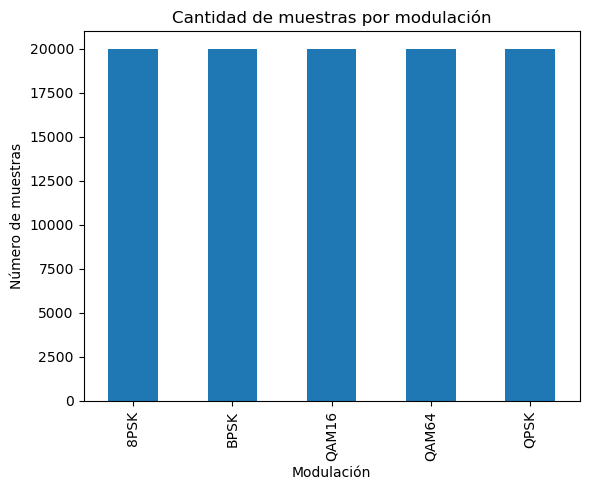

In [10]:
class_counts.plot(kind="bar")
plt.title("Cantidad de muestras por modulación")
plt.xlabel("Modulación")
plt.ylabel("Número de muestras")
plt.show()

### Distribución por SNR

In [11]:
snr_counts = df_selected.groupby("snr")["num_samples"].sum()
print(snr_counts)

snr
-20    5000
-18    5000
-16    5000
-14    5000
-12    5000
-10    5000
-8     5000
-6     5000
-4     5000
-2     5000
 0     5000
 2     5000
 4     5000
 6     5000
 8     5000
 10    5000
 12    5000
 14    5000
 16    5000
 18    5000
Name: num_samples, dtype: int64


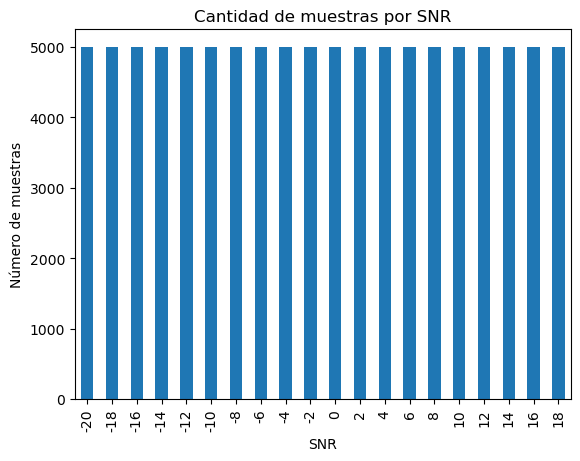

In [12]:
snr_counts.plot(kind="bar")
plt.title("Cantidad de muestras por SNR")
plt.xlabel("SNR")
plt.ylabel("Número de muestras")
plt.show()

### Distribución cruzada modulación-SNR

In [13]:
pivot = df_selected.pivot_table(
    values="num_samples",
    index="modulation",
    columns="snr",
    aggfunc="sum"
)

pivot

snr,-20,-18,-16,-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8,10,12,14,16,18
modulation,,,,,,,,,,,,,,,,,,,,
8PSK,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
BPSK,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
QAM16,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
QAM64,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
QPSK,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000


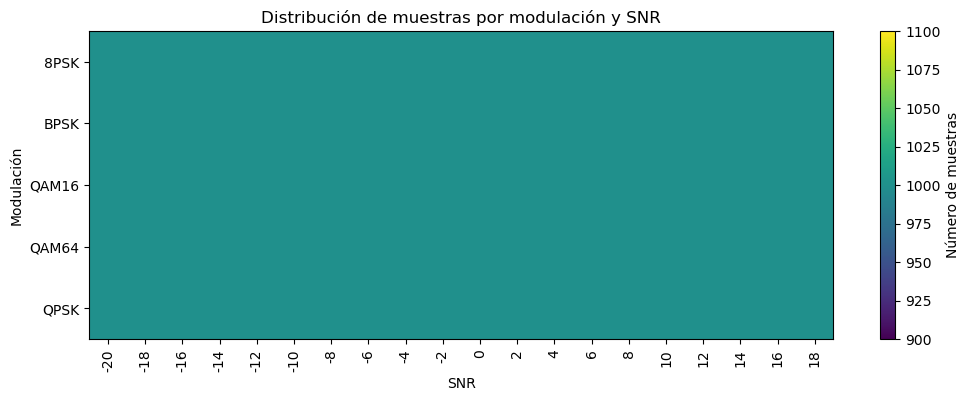

In [14]:
plt.figure(figsize=(12, 4))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Número de muestras")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Distribución de muestras por modulación y SNR")
plt.xlabel("SNR")
plt.ylabel("Modulación")
plt.show()

### Construir dataset final X, y, SNR

In [15]:
X = []
y = []
snr_values = []

for (mod, snr), samples in data.items():
    if mod in selected_mods:
        X.append(samples)
        y.extend([mod] * samples.shape[0])
        snr_values.extend([snr] * samples.shape[0])

X = np.vstack(X)
y = np.array(y)
snr_values = np.array(snr_values)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("snr shape:", snr_values.shape)

X shape: (100000, 2, 128)
y shape: (100000,)
snr shape: (100000,)


In [16]:
X_flat = X.reshape(X.shape[0], -1)

print("X para MLP:", X_flat.shape)

X para MLP: (100000, 256)


### Faltantes, infinitos o anómalos

In [17]:
print("NaN:", np.isnan(X).sum())
print("Inf:", np.isinf(X).sum())

print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())
print("Media:", X.mean())
print("Desviación estándar:", X.std())


NaN: 0
Inf: 0
Valor mínimo: -0.15494554
Valor máximo: 0.16422912
Media: -4.7892547e-05
Desviación estándar: 0.0060583474


### Señales IQ en el tiempo

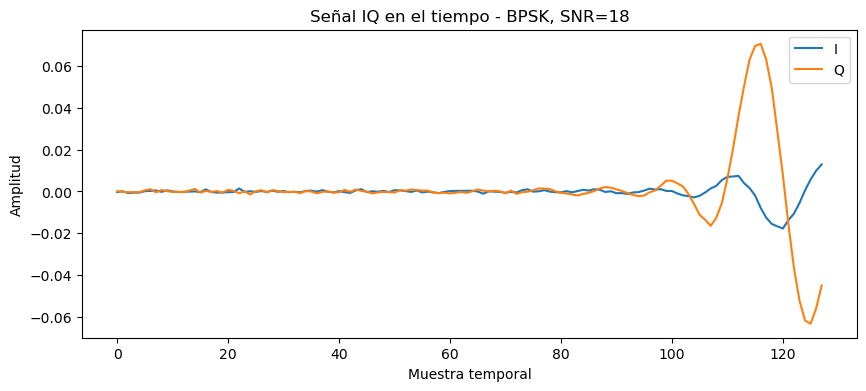

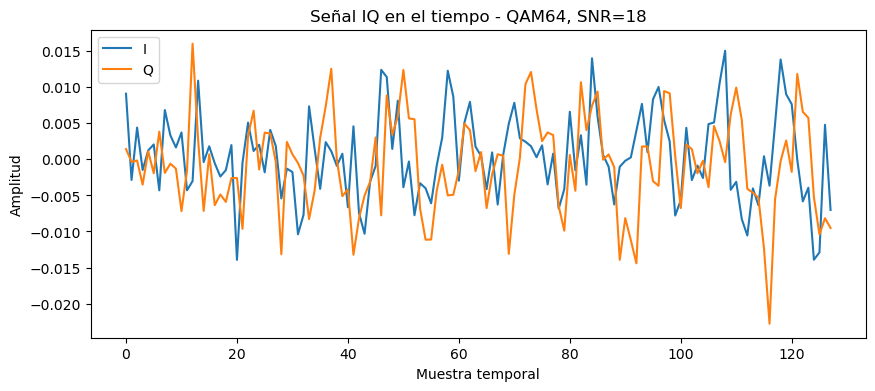

In [18]:
def plot_iq_signal(X, y, snr_values, modulation, snr, index=0):
    idx = np.where((y == modulation) & (snr_values == snr))[0]
    sample = X[idx[index]]
    
    I = sample[0]
    Q = sample[1]
    
    plt.figure(figsize=(10, 4))
    plt.plot(I, label="I")
    plt.plot(Q, label="Q")
    plt.title(f"Señal IQ en el tiempo - {modulation}, SNR={snr}")
    plt.xlabel("Muestra temporal")
    plt.ylabel("Amplitud")
    plt.legend()
    plt.show()

plot_iq_signal(X, y, snr_values, "BPSK", 18)
plot_iq_signal(X, y, snr_values, "QAM64", 18)

### Constelaciones

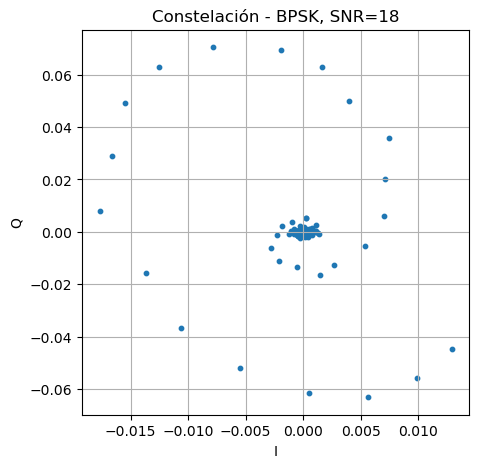

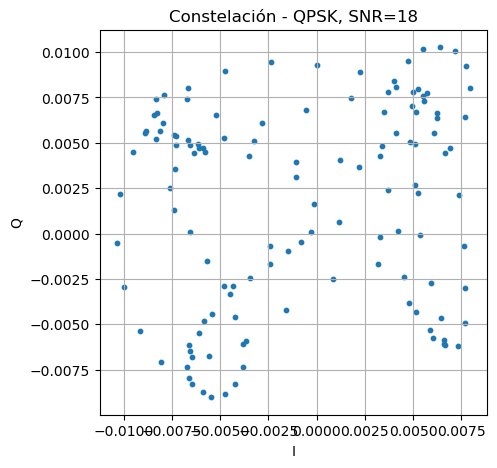

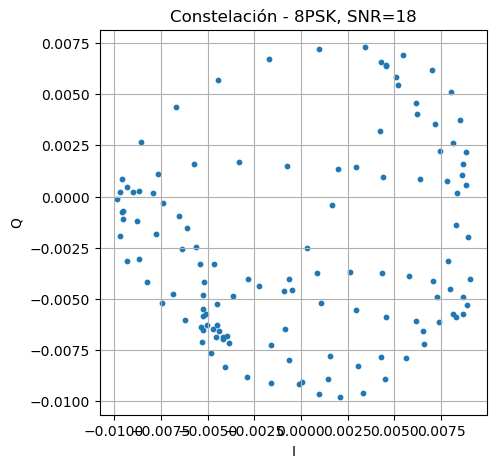

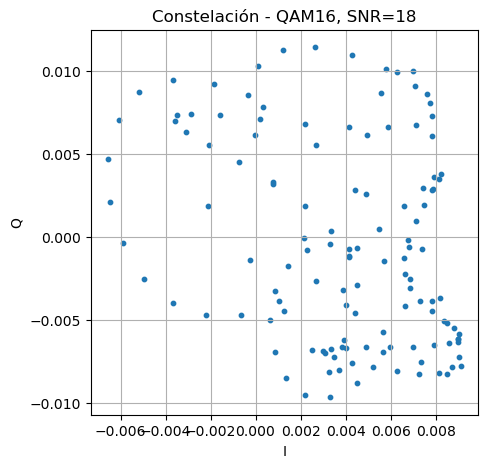

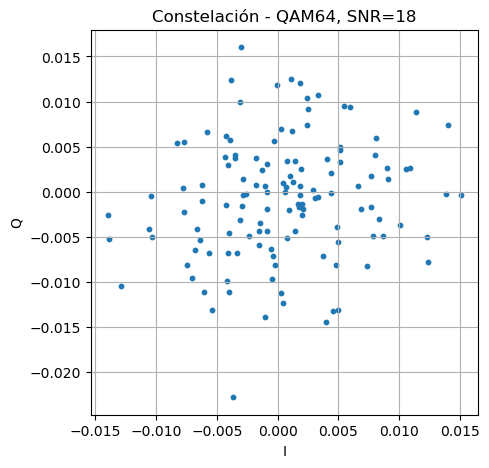

In [19]:
def plot_constellation(X, y, snr_values, modulation, snr, index=0):
    idx = np.where((y == modulation) & (snr_values == snr))[0]
    sample = X[idx[index]]
    
    I = sample[0]
    Q = sample[1]
    
    plt.figure(figsize=(5, 5))
    plt.scatter(I, Q, s=10)
    plt.title(f"Constelación - {modulation}, SNR={snr}")
    plt.xlabel("I")
    plt.ylabel("Q")
    plt.grid(True)
    plt.show()

for mod in selected_mods:
    plot_constellation(X, y, snr_values, mod, 18)


In [20]:
def compare_constellation_snr(X, y, snr_values, modulation, snr_high=18, snr_low=-10, index=0):
    # Índices para SNR alto
    idx_high = np.where((y == modulation) & (snr_values == snr_high))[0]
    sample_high = X[idx_high[index]]
    
    I_high = sample_high[0]
    Q_high = sample_high[1]
    
    # Índices para SNR bajo
    idx_low = np.where((y == modulation) & (snr_values == snr_low))[0]
    sample_low = X[idx_low[index]]
    
    I_low = sample_low[0]
    Q_low = sample_low[1]
    
    # Gráficas comparativas
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    axes[0].scatter(I_high, Q_high, s=10)
    axes[0].set_title(f"{modulation}, SNR={snr_high}")
    axes[0].set_xlabel("I")
    axes[0].set_ylabel("Q")
    axes[0].grid(True)
    axes[0].axis("equal")
    
    axes[1].scatter(I_low, Q_low, s=10)
    axes[1].set_title(f"{modulation}, SNR={snr_low}")
    axes[1].set_xlabel("I")
    axes[1].set_ylabel("Q")
    axes[1].grid(True)
    axes[1].axis("equal")
    
    plt.suptitle(f"Comparación de constelaciones para {modulation}")
    plt.show()

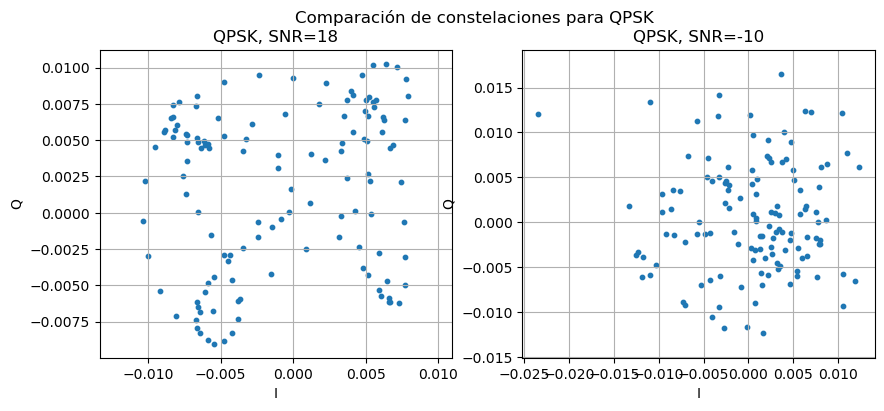

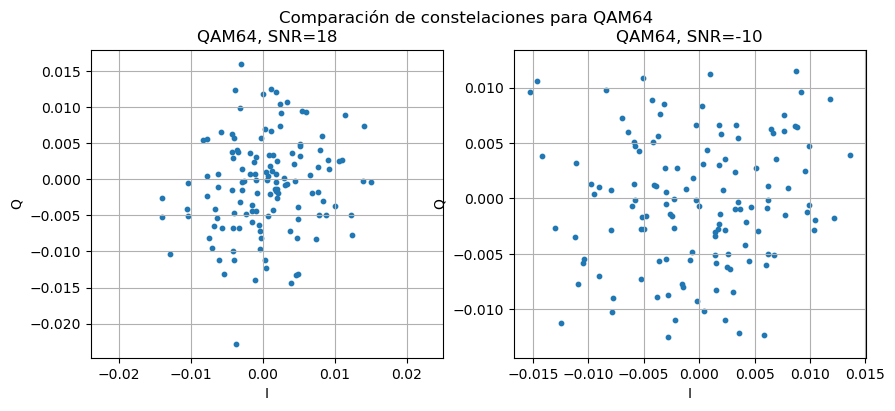

In [21]:
compare_constellation_snr(X, y, snr_values, "QPSK", 18, -10)
compare_constellation_snr(X, y, snr_values, "QAM64", 18, -10)

### Analizar amplitud y fase

In [22]:
I = X[:, 0, :]
Q = X[:, 1, :]

amplitude = np.sqrt(I**2 + Q**2)
phase = np.arctan2(Q, I)

print("Amplitude shape:", amplitude.shape)
print("Phase shape:", phase.shape)

Amplitude shape: (100000, 128)
Phase shape: (100000, 128)


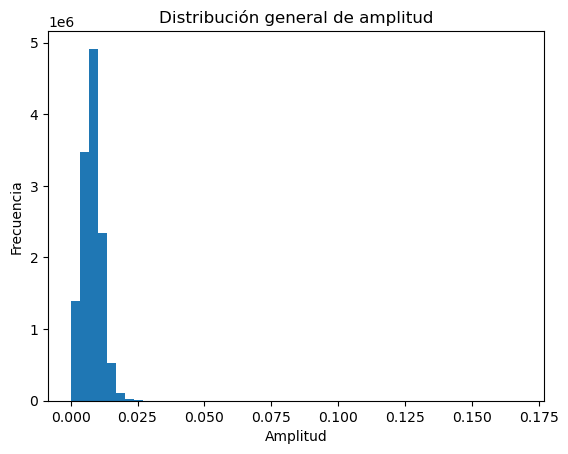

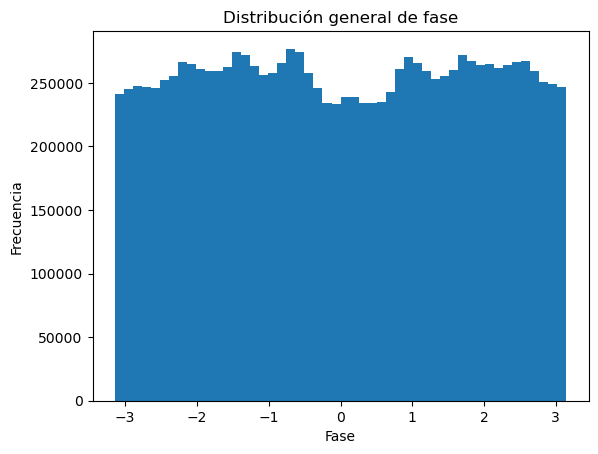

In [23]:
plt.hist(amplitude.flatten(), bins=50)
plt.title("Distribución general de amplitud")
plt.xlabel("Amplitud")
plt.ylabel("Frecuencia")
plt.show()

plt.hist(phase.flatten(), bins=50)
plt.title("Distribución general de fase")
plt.xlabel("Fase")
plt.ylabel("Frecuencia")
plt.show()

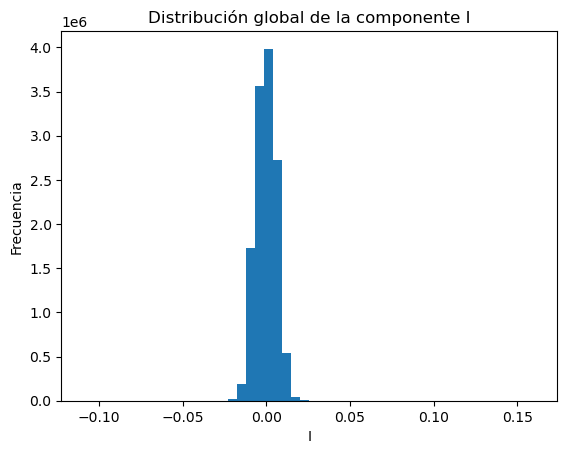

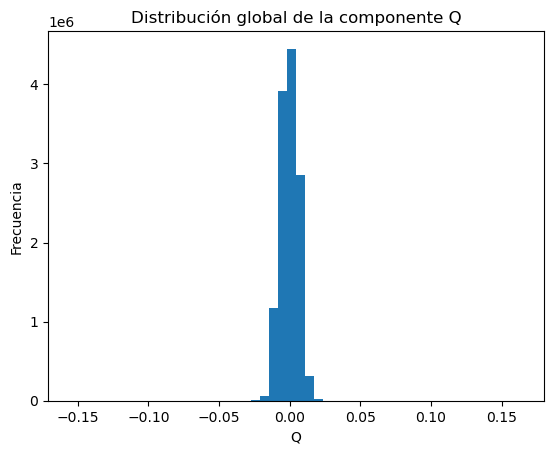

In [24]:
# Distribución global de I y Q
I = X[:, 0, :]
Q = X[:, 1, :]

plt.hist(I.flatten(), bins=50)
plt.title("Distribución global de la componente I")
plt.xlabel("I")
plt.ylabel("Frecuencia")
plt.show()

plt.hist(Q.flatten(), bins=50)
plt.title("Distribución global de la componente Q")
plt.xlabel("Q")
plt.ylabel("Frecuencia")
plt.show()

### Potencia promedio por modulación

In [25]:
power = np.mean(I**2 + Q**2, axis=1)

df_features = pd.DataFrame({
    "modulation": y,
    "snr": snr_values,
    "power": power
})

df_features.groupby("modulation")["power"].describe()

,count,mean,std,min,25%,50%,75%,max
modulation,,,,,,,,
8PSK,20000.0,0.000072,0.000009,0.000062,0.000066,0.000073,0.000078,0.000491
BPSK,20000.0,0.000074,0.000007,0.000063,0.000070,0.000074,0.000078,0.000533
QAM16,20000.0,0.000074,0.000009,0.000064,0.000070,0.000073,0.000077,0.000647
QAM64,20000.0,0.000074,0.000011,0.000064,0.000071,0.000073,0.000076,0.000519
QPSK,20000.0,0.000072,0.000009,0.000062,0.000066,0.000073,0.000078,0.000477


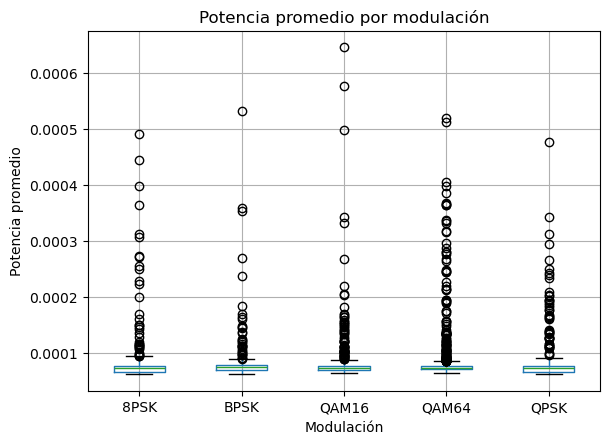

In [26]:
df_features.boxplot(column="power", by="modulation")
plt.title("Potencia promedio por modulación")
plt.suptitle("")
plt.xlabel("Modulación")
plt.ylabel("Potencia promedio")
plt.show()

El dataset seleccionado contiene 100 000 señales IQ correspondientes a cinco modulaciones digitales: BPSK, QPSK, 8PSK, QAM16 y QAM64. Cada señal tiene dos componentes, I y Q, con 128 muestras temporales, lo que produce 256 características al preparar los datos para una red neuronal MLP. El análisis mostró que el conjunto está balanceado por clase y por nivel de SNR, con 20 000 muestras por modulación y 5000 muestras por cada nivel de SNR.

Además, no se encontraron valores faltantes ni infinitos. Los valores IQ se encuentran normalizados alrededor de cero, con un rango aproximado entre -0.155 y 0.164. Las gráficas de señales IQ, amplitud, fase y potencia muestran que los datos corresponden a señales crudas y normalizadas, no a símbolos demodulados ideales. Por esta razón, las constelaciones no aparecen como puntos perfectos, sino como nubes, trayectorias o agrupaciones afectadas por transiciones, ruido y variaciones propias de la señal.

Finalmente, la potencia promedio calculada corresponde a una potencia normalizada en unidades arbitrarias, no a watts ni dBm. Las potencias promedio son similares entre modulaciones, lo que sugiere que la clasificación no puede basarse únicamente en la energía de la señal, sino que requiere aprender patrones más complejos de las componentes IQ.

## Feature Extraction

No se realiza una etapa adicional de *Feature Extraction*, debido a que el objetivo principal es evaluar la capacidad de una red neuronal MLP para clasificar modulaciones digitales directamente a partir de las señales IQ originales.

El dataset RML2016.10A proporciona cada señal mediante dos componentes: \(I\), correspondiente a la componente en fase, y \(Q\), correspondiente a la componente en cuadratura. Estas componentes ya contienen información relevante sobre amplitud, fase, comportamiento temporal y efecto del ruido representado por el SNR.

Cada señal tiene dimensión \(2 \times 128\), es decir, 128 muestras temporales de la componente \(I\) y 128 muestras temporales de la componente \(Q\). Para utilizar modelos de `sklearn`, cada señal se aplana en un vector de 256 características. Este proceso no se considera extracción manual de características, sino una adaptación de formato necesaria para utilizar una MLP.

Además, no se utiliza *transfer learning*, por lo que no se emplea un modelo preentrenado como extractor automático de características. En consecuencia, el modelo trabajará directamente con las muestras IQ crudas y se aplicará posteriormente una técnica de *Feature Selection* tipo filtro dentro del pipeline.

## Preparación para modelado

Después del EDA, se prepara el conjunto de datos para ser utilizado por los modelos de machine learning. Como cada señal IQ tiene forma \(2 \times 128\), se aplana cada señal para obtener un vector de 256 características. Luego, las etiquetas de modulación se codifican numéricamente y se divide el dataset en conjuntos de entrenamiento y prueba.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Aplanar señales IQ 
X_flat = X.reshape(X.shape[0], -1)

print("Forma original de X:", X.shape)
print("Forma aplanada de X:", X_flat.shape)

Forma original de X: (100000, 2, 128)
Forma aplanada de X: (100000, 256)


In [28]:
# Codificar etiquetas de modulación
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Clases originales:", label_encoder.classes_)
print("Primeras etiquetas codificadas:", y_encoded[:10])

Clases originales: ['8PSK' 'BPSK' 'QAM16' 'QAM64' 'QPSK']
Primeras etiquetas codificadas: [4 4 4 4 4 4 4 4 4 4]


In [29]:
# Estratificación combinando modulación y SNR
stratify_key = np.array([f"{mod}_{snr}" for mod, snr in zip(y, snr_values)])

X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(
    X_flat,
    y_encoded,
    snr_values,
    test_size=0.2,
    random_state=42,
    stratify=stratify_key
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("snr_train:", snr_train.shape)
print("snr_test:", snr_test.shape)

X_train: (80000, 256)
X_test: (20000, 256)
y_train: (80000,)
y_test: (20000,)
snr_train: (80000,)
snr_test: (20000,)


## Pipelines y Feature Selection

Se utilizan pipelines de  para integrar el preprocesamiento, la selección de características y el entrenamiento de los modelos en un único flujo de trabajo.

Cada pipeline incluye:

1. `StandardScaler`: estandariza las variables de entrada.
2. `SelectKBest`: aplica selección de características tipo filtro.
3. Modelo de clasificación: MLP o Regresión Logística L2.

La selección de características se realiza con `SelectKBest` y `f_classif`. Esta técnica evalúa la relación estadística entre cada característica y la clase objetivo, seleccionando las variables más relevantes. Al incluirla dentro del pipeline, se evita fuga de información, ya que la selección se ajusta únicamente con los datos de entrenamiento durante cada partición de validación cruzada.

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Pipeline MLP

##### Modelo principal: Red Neuronal MLP

El modelo principal es una red neuronal MLP. Este modelo recibe como entrada los 256 valores IQ de cada señal aplanada. La arquitectura inicial utiliza dos capas ocultas, una de 128 neuronas y otra de 64 neuronas, con función de activación ReLU.

La MLP se utiliza porque puede aprender relaciones no lineales entre las muestras IQ y las clases de modulación.

In [31]:
pipeline_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_selection", SelectKBest(score_func=f_classif, k=128)),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=100,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ))
])

pipeline_mlp

,steps,"[('scaler', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,score_func,<function f_c...0027C1D508400>
,k,128
,hidden_layer_sizes,"(128, ...)"
,activation,'relu'


## Pipeline Regresión Logística L2

#### Modelo base: Regresión Logística con regularización L2

Como modelo base se utiliza Regresión Logística con regularización L2. Este modelo es un clasificador lineal regularizado y permite comparar si la MLP, al ser un modelo no lineal, logra mejorar el desempeño frente a una técnica más simple.

La regularización L2 penaliza pesos excesivamente grandes, ayudando a reducir el sobreajuste. En este modelo, el hiperparámetro principal es \(C\), que controla la fuerza de regularización. Valores pequeños de \(C\) implican mayor regularización, mientras que valores grandes reducen la penalización.

In [32]:
pipeline_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_selection", SelectKBest(score_func=f_classif, k=128)),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=1000
    ))
])

pipeline_logreg

,steps,"[('scaler', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,score_func,<function f_c...0027C1D508400>
,k,128
,penalty,'l2'
,dual,False


## Entrenamiento inicial de ambos modelos

#### Entrenamiento inicial de ambos modelos

Antes de optimizar hiperparámetros, se entrenan versiones iniciales de la MLP y de la Regresión Logística L2. Esto permite obtener una primera línea base de desempeño para comparar cómo se comportan ambos modelos sin ajuste fino.

In [33]:
def evaluar_modelo(modelo, X_test, y_test, nombre_modelo):
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Accuracy {nombre_modelo}: {acc:.4f}")
    print()
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))
    
    cm = confusion_matrix(y_test, y_pred)
    
    fig, ax = plt.subplots(figsize=(7, 7))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )
    disp.plot(ax=ax, values_format="d")
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()
    
    return y_pred, acc

Accuracy MLP inicial: 0.3421

              precision    recall  f1-score   support

        8PSK       0.25      0.25      0.25      4000
        BPSK       0.61      0.67      0.64      4000
       QAM16       0.26      0.19      0.22      4000
       QAM64       0.30      0.43      0.35      4000
        QPSK       0.25      0.17      0.20      4000

    accuracy                           0.34     20000
   macro avg       0.33      0.34      0.33     20000
weighted avg       0.33      0.34      0.33     20000



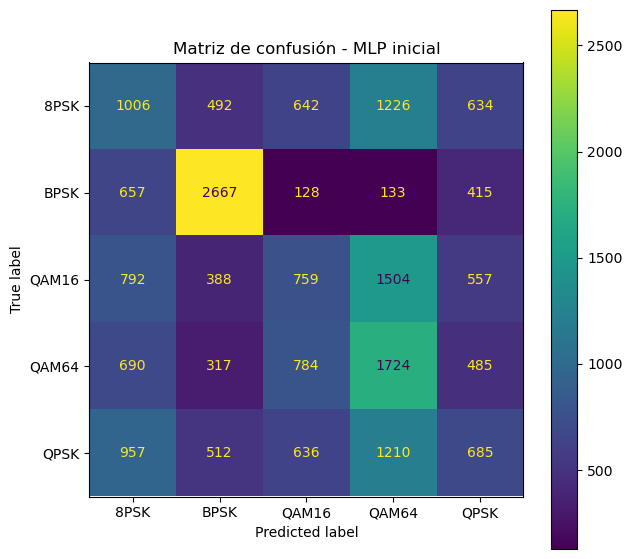

In [34]:
# Entrenamiento inicial MLP
pipeline_mlp.fit(X_train, y_train)

y_pred_mlp_initial, accuracy_mlp_initial = evaluar_modelo(
    pipeline_mlp,
    X_test,
    y_test,
    "MLP inicial"
)

Accuracy Regresión Logística L2 inicial: 0.2054

              precision    recall  f1-score   support

        8PSK       0.21      0.20      0.20      4000
        BPSK       0.20      0.20      0.20      4000
       QAM16       0.21      0.22      0.22      4000
       QAM64       0.20      0.21      0.21      4000
        QPSK       0.21      0.21      0.21      4000

    accuracy                           0.21     20000
   macro avg       0.21      0.21      0.21     20000
weighted avg       0.21      0.21      0.21     20000



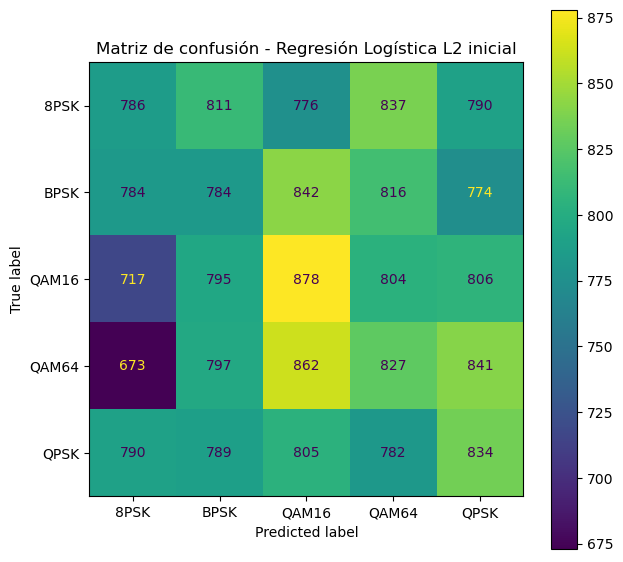

In [35]:
# Entrenamiento inicial Regresión Logística L2
pipeline_logreg.fit(X_train, y_train)

y_pred_logreg_initial, accuracy_logreg_initial = evaluar_modelo(
    pipeline_logreg,
    X_test,
    y_test,
    "Regresión Logística L2 inicial"
)

#### Optimización de hiperparámetros

La optimización de hiperparámetros se realiza mediante `GridSearchCV` con `RepeatedStratifiedKFold`. Debido al tamaño del dataset, se utiliza una muestra del conjunto de entrenamiento para reducir el costo computacional.

Se optimizan los hiperparámetros de la MLP y de la Regresión Logística L2. Esto permite realizar una comparación más justa entre ambos modelos, ya que no se compara un modelo optimizado contra otro sin optimizar.

En la MLP se optimizan:

- número de características seleccionadas por `SelectKBest`;
- arquitectura de capas ocultas;
- parámetro de regularización `alpha`;
- tasa de aprendizaje inicial.

En la Regresión Logística L2 se optimizan:

- número de características seleccionadas por `SelectKBest`;
- parámetro \(C\), asociado a la fuerza de regularización.

In [47]:
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

# Muestra para optimización
OPT_SIZE = 20000

X_train_opt, _, y_train_opt, _ = train_test_split(
    X_train,
    y_train,
    train_size=OPT_SIZE,
    random_state=42,
    stratify=y_train
)

print("Tamaño usado para optimización:", X_train_opt.shape)

Tamaño usado para optimización: (20000, 256)


In [48]:
cv_opt = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=42
)

## Optimizar MLP

In [38]:
param_grid_mlp = {
    "feature_selection__k": [64, 128, 256],
    "mlp__hidden_layer_sizes": [(64,), (128,), (128, 64)],
    "mlp__alpha": [0.00001, 0.0001, 0.001, 0.01],
    "mlp__learning_rate_init": [0.001, 0.0005]
}

grid_search_mlp = GridSearchCV(
    estimator=pipeline_mlp,
    param_grid=param_grid_mlp,
    scoring="accuracy",
    cv=cv_opt,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search_mlp.fit(X_train_opt, y_train_opt)

print("Mejores hiperparámetros MLP:")
print(grid_search_mlp.best_params_)

print("Mejor accuracy promedio en CV:")
print(grid_search_mlp.best_score_)

Fitting 10 folds for each of 72 candidates, totalling 720 fits
Mejores hiperparámetros MLP:
{'feature_selection__k': 64, 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (128,), 'mlp__learning_rate_init': 0.0005}
Mejor accuracy promedio en CV:
0.270325


## Optimizar Regresión Logística L2

In [39]:
param_grid_logreg = {
    "feature_selection__k": [64, 128, 256],
    "logreg__C": [0.01, 0.1, 1, 10, 100]
}

grid_search_logreg = GridSearchCV(
    estimator=pipeline_logreg,
    param_grid=param_grid_logreg,
    scoring="accuracy",
    cv=cv_opt,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search_logreg.fit(X_train_opt, y_train_opt)

print("Mejores hiperparámetros Regresión Logística L2:")
print(grid_search_logreg.best_params_)

print("Mejor accuracy promedio en CV:")
print(grid_search_logreg.best_score_)

Fitting 10 folds for each of 15 candidates, totalling 150 fits
Mejores hiperparámetros Regresión Logística L2:
{'feature_selection__k': 128, 'logreg__C': 0.01}
Mejor accuracy promedio en CV:
0.20252499999999998


## Gráficas de optimización de hiperparámetros

Se grafica el error promedio de entrenamiento y validación cruzada frente a un hiperparámetro del modelo.

En la MLP se analiza el parámetro `alpha`, que corresponde a la regularización L2 interna del modelo. Valores muy bajos de regularización pueden favorecer sobreajuste, mientras que valores muy altos pueden generar subajuste.

En la Regresión Logística L2 se analiza el parámetro \(C\). Este parámetro es inverso a la fuerza de regularización: valores pequeños de \(C\) aplican mayor regularización, mientras que valores grandes aplican menor regularización.

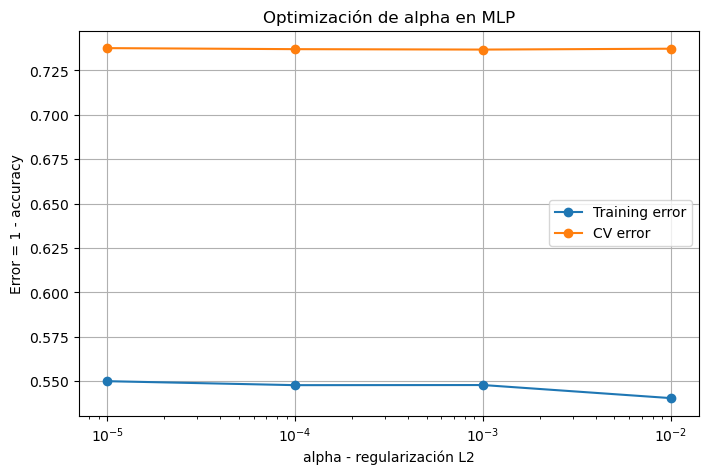

,param_mlp__alpha,mean_train_score,mean_test_score,train_error,cv_error
0,0.00001,0.449978,0.262475,0.550022,0.737525
1,0.00010,0.452215,0.263057,0.547785,0.736943
2,0.00100,0.452149,0.263293,0.547851,0.736707
3,0.01000,0.459514,0.262804,0.540486,0.737196


In [40]:
results_mlp = pd.DataFrame(grid_search_mlp.cv_results_)

# Agrupar resultados por alpha
mlp_alpha_curve = results_mlp.groupby("param_mlp__alpha").agg({
    "mean_train_score": "mean",
    "mean_test_score": "mean"
}).reset_index()

mlp_alpha_curve["train_error"] = 1 - mlp_alpha_curve["mean_train_score"]
mlp_alpha_curve["cv_error"] = 1 - mlp_alpha_curve["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.plot(
    mlp_alpha_curve["param_mlp__alpha"],
    mlp_alpha_curve["train_error"],
    marker="o",
    label="Training error"
)
plt.plot(
    mlp_alpha_curve["param_mlp__alpha"],
    mlp_alpha_curve["cv_error"],
    marker="o",
    label="CV error"
)

plt.xscale("log")
plt.title("Optimización de alpha en MLP")
plt.xlabel("alpha - regularización L2")
plt.ylabel("Error = 1 - accuracy")
plt.legend()
plt.grid(True)
plt.show()

mlp_alpha_curve

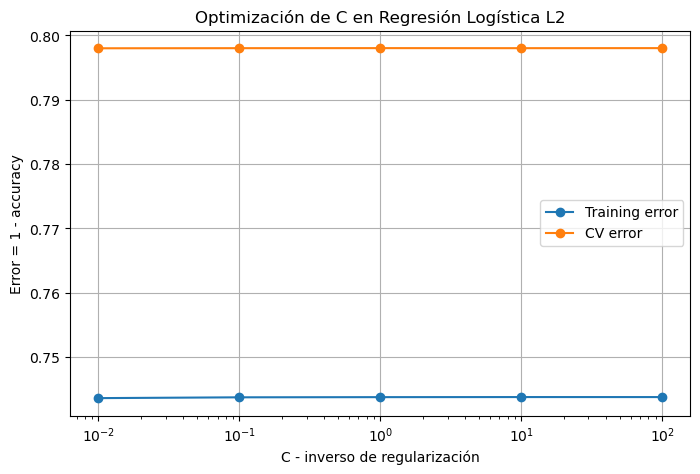

,param_logreg__C,mean_train_score,mean_test_score,train_error,cv_error
0,0.01,0.256365,0.202000,0.743635,0.798000
1,0.10,0.256240,0.201983,0.743760,0.798017
2,1.00,0.256213,0.201975,0.743788,0.798025
3,10.00,0.256200,0.201983,0.743800,0.798017
4,100.00,0.256202,0.201975,0.743798,0.798025


In [41]:
results_logreg = pd.DataFrame(grid_search_logreg.cv_results_)

# Agrupar resultados por C
logreg_c_curve = results_logreg.groupby("param_logreg__C").agg({
    "mean_train_score": "mean",
    "mean_test_score": "mean"
}).reset_index()

logreg_c_curve["train_error"] = 1 - logreg_c_curve["mean_train_score"]
logreg_c_curve["cv_error"] = 1 - logreg_c_curve["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.plot(
    logreg_c_curve["param_logreg__C"],
    logreg_c_curve["train_error"],
    marker="o",
    label="Training error"
)
plt.plot(
    logreg_c_curve["param_logreg__C"],
    logreg_c_curve["cv_error"],
    marker="o",
    label="CV error"
)

plt.xscale("log")
plt.title("Optimización de C en Regresión Logística L2")
plt.xlabel("C - inverso de regularización")
plt.ylabel("Error = 1 - accuracy")
plt.legend()
plt.grid(True)
plt.show()

logreg_c_curve

## Entrenar mejores modelos

In [42]:
best_mlp = grid_search_mlp.best_estimator_
best_logreg = grid_search_logreg.best_estimator_

# Entrenar con todo el conjunto de entrenamiento
best_mlp.fit(X_train, y_train)
best_logreg.fit(X_train, y_train)

,steps,"[('scaler', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,score_func,<function f_c...0027C1D508400>
,k,128
,penalty,'l2'
,dual,False


## Evaluar mejores modelos en test

#### Evaluación de los mejores modelos en test

Se evalúan los modelos optimizados sobre el conjunto de prueba. Esta evaluación permite estimar el desempeño final de cada modelo sobre datos que no fueron utilizados durante el entrenamiento ni durante la optimización.

Accuracy Mejor MLP: 0.2892

              precision    recall  f1-score   support

        8PSK       0.23      0.16      0.19      4000
        BPSK       0.41      0.49      0.44      4000
       QAM16       0.24      0.22      0.23      4000
       QAM64       0.29      0.35      0.32      4000
        QPSK       0.24      0.22      0.23      4000

    accuracy                           0.29     20000
   macro avg       0.28      0.29      0.28     20000
weighted avg       0.28      0.29      0.28     20000



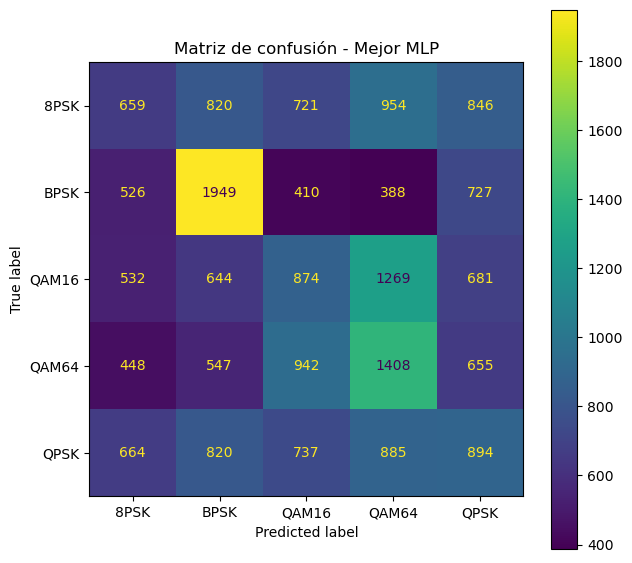

In [43]:
y_pred_best_mlp, accuracy_best_mlp = evaluar_modelo(
    best_mlp,
    X_test,
    y_test,
    "Mejor MLP"
)

Accuracy Mejor Regresión Logística L2: 0.2057

              precision    recall  f1-score   support

        8PSK       0.21      0.20      0.20      4000
        BPSK       0.20      0.20      0.20      4000
       QAM16       0.21      0.22      0.22      4000
       QAM64       0.20      0.21      0.21      4000
        QPSK       0.21      0.21      0.21      4000

    accuracy                           0.21     20000
   macro avg       0.21      0.21      0.21     20000
weighted avg       0.21      0.21      0.21     20000



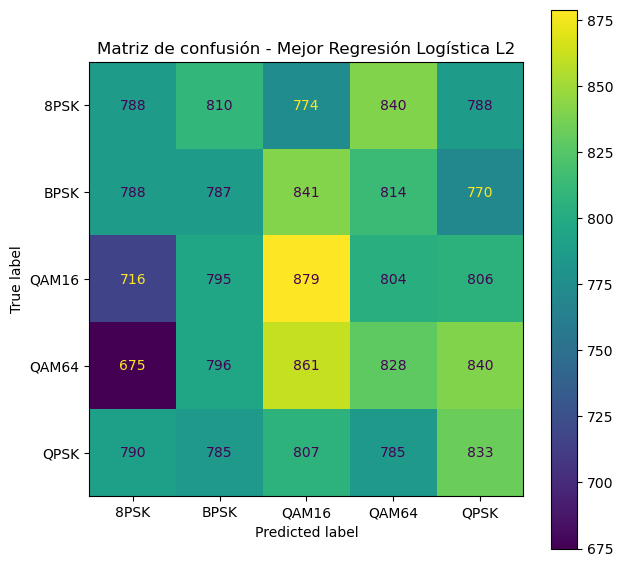

In [44]:
y_pred_best_logreg, accuracy_best_logreg = evaluar_modelo(
    best_logreg,
    X_test,
    y_test,
    "Mejor Regresión Logística L2"
)

In [45]:
print("Resumen de accuracies:")
print("MLP inicial:", accuracy_mlp_initial)
print("Regresión Logística L2 inicial:", accuracy_logreg_initial)
print("Mejor MLP:", accuracy_best_mlp)
print("Mejor Regresión Logística L2:", accuracy_best_logreg)

Resumen de accuracies:
MLP inicial: 0.34205
Regresión Logística L2 inicial: 0.20545
Mejor MLP: 0.2892
Mejor Regresión Logística L2: 0.20575


## Evaluación por SNR

#### Evaluación por nivel de SNR

Como el dataset contiene señales con diferentes niveles de SNR, se analiza el accuracy del mejor modelo MLP según el nivel de ruido. Esto permite evaluar si el modelo clasifica mejor cuando la señal tiene menos ruido y si presenta dificultades cuando el SNR es bajo.

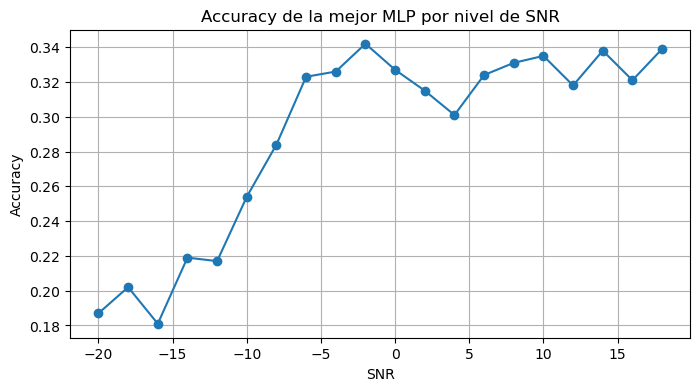

snr
-20    0.187
-18    0.202
-16    0.181
-14    0.219
-12    0.217
-10    0.254
-8     0.284
-6     0.323
-4     0.326
-2     0.342
 0     0.327
 2     0.315
 4     0.301
 6     0.324
 8     0.331
 10    0.335
 12    0.318
 14    0.338
 16    0.321
 18    0.339
Name: correct, dtype: float64

In [46]:
df_eval_snr = pd.DataFrame({
    "y_true": label_encoder.inverse_transform(y_test),
    "y_pred": label_encoder.inverse_transform(y_pred_best_mlp),
    "snr": snr_test
})

df_eval_snr["correct"] = df_eval_snr["y_true"] == df_eval_snr["y_pred"]

accuracy_by_snr = df_eval_snr.groupby("snr")["correct"].mean()

plt.figure(figsize=(8, 4))
plt.plot(accuracy_by_snr.index, accuracy_by_snr.values, marker="o")
plt.title("Accuracy de la mejor MLP por nivel de SNR")
plt.xlabel("SNR")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

accuracy_by_snr

## Comparación estadística entre dos técnicas ML